In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
import re
import networkx as nx
from itertools import combinations

### conversion to pd df

In [2]:
df_users = pd.read_csv('DATA2/users.csv')
print(df_users.shape)
df_users.head(2)

(2810, 5)


,id,name,address,phone,email
0,53386,Jacqulyn Mante,"566 Emelina Turnpike, Lashundaside, NE 78034-5281",962.715.8009,leonardo.leannon@wintheiser-lueilwitz.example
1,54635,Devon Leannon III,,(537) 133-9394,jon_torp@bayer.example


In [3]:
df_orders = pd.read_parquet('DATA2/orders.parquet', engine='pyarrow')
print(df_orders.shape)
df_orders.head(2)

(9850, 7)


,id,user_id,book_id,quantity,unit_price,timestamp,shipping
0,75198,55590,21465,1,73.5$,"08:47:31 P.M.,10/07/24",NULL
1,82023,53482,21374,1,$25.00,2024-09-11T05:27:49,NULL


In [4]:
with open('DATA2/books.yaml', 'r') as f:
    books_data = yaml.safe_load(f)

df_books = pd.DataFrame(books_data)
print(df_books.shape)
df_books.columns = df_books.columns.str.lstrip(':')

(741, 6)


In [5]:
df_books.head(2)

,id,title,author,genre,publisher,year
0,21326,Behold the Man,"Trenton Sipes, Clint Hauck VM",Reference book,Bowes & Bowes,1979
1,21546,The Deer Hunter,Norris Gusikowski,Reference book,Koren Publishers Jerusalem,1993


### nulls in data

In [6]:
users_total_nulls = df_users.isnull().sum().sum()
print(f"Total users missing values: {users_total_nulls}")

Total users missing values: 97


In [7]:
orders_total_nulls = df_orders.isnull().sum().sum()
print(f"Total orders missing values: {orders_total_nulls}")

Total orders missing values: 2383


In [8]:
books_total_nulls = df_books.isnull().sum().sum()
print(f"Total books missing values: {books_total_nulls}")

Total books missing values: 8


In [9]:
users_nulls = df_users.isnull().sum()
print("df_users: null columns:")
print(users_nulls[users_nulls > 0], "\n")

orders_nulls = df_orders.isnull().sum()
print("df_orders: null columns:")
print(orders_nulls[orders_nulls > 0], "\n")

books_nulls = df_books.isnull().sum()
print("df_books: null columns:")
print(books_nulls[books_nulls > 0], "\n")

df_users: null columns:
address    97
dtype: int64 

df_orders: null columns:
shipping    2383
dtype: int64 

df_books: null columns:
publisher    6
year         2
dtype: int64 



### feature processing & engineering

##### money

In [10]:
df_orders["unit_price"].head(2)

0     73.5$
1    $25.00
Name: unit_price, dtype: str

In [11]:
def convert_to_usd(value):
    clean_val = re.sub(r'[¢]', '.', str(value))
    
    amount_match = re.search(r'(\d+\.?\d*)', clean_val)
    if not amount_match:
        return 0.0
    
    amount = float(amount_match.group(1))
    
    if any(x in clean_val.upper() for x in ['€', 'EUR']):
        amount *= 1.2
        
    return round(amount, 2)

In [12]:
df_orders['unit_price'] = df_orders['unit_price'].apply(convert_to_usd)
df_orders['unit_price'].head(2)

0    73.5
1    25.0
Name: unit_price, dtype: float64

In [13]:
df_orders['paid_price'] = df_orders['quantity'] * df_orders['unit_price']

In [14]:
df_orders.head(2)

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,paid_price
0,75198,55590,21465,1,73.5,"08:47:31 P.M.,10/07/24",NULL,73.5
1,82023,53482,21374,1,25.0,2024-09-11T05:27:49,NULL,25.0


##### dates

In [15]:
df_orders['timestamp'].head()

0    08:47:31 P.M.,10/07/24
1       2024-09-11T05:27:49
2          2024-08-06,06:53
3      03/18/25;09:32:41 AM
4      04:55:14 pm,09/24/24
Name: timestamp, dtype: str

In [16]:
clean_timestamps = (
    df_orders['timestamp']
    .str.replace(r'([AP])\.M\.', r'\1M', regex=True, case=False)
    .str.replace(r'[,;]', ' ', regex=True)
)

df_orders['date_extracted'] = pd.to_datetime(clean_timestamps, format='mixed').dt.date

In [17]:
df_orders.head()

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,paid_price,date_extracted
0,75198,55590,21465,1,73.5,"08:47:31 P.M.,10/07/24",NULL,73.5,2024-10-07
1,82023,53482,21374,1,25.0,2024-09-11T05:27:49,NULL,25.0,2024-09-11
2,81439,55123,21408,1,22.5,"2024-08-06,06:53",,22.5,2024-08-06
3,80259,54387,21013,1,42.5,03/18/25;09:32:41 AM,,42.5,2025-03-18
4,80176,54916,21437,1,62.5,"04:55:14 pm,09/24/24",NULL,62.5,2024-09-24


### metrics

#### money date metrics

In [18]:
daily_rev = df_orders.groupby('date_extracted')['paid_price'].sum().reset_index()
daily_rev = daily_rev.sort_values('date_extracted') # Ensure chronological order

print("daily revenue:")
daily_rev.head(2)

daily revenue:


,date_extracted,paid_price
0,2023-12-24,51.9
1,2023-12-26,23.4


In [19]:
top_5_days = daily_rev.sort_values(by='paid_price', ascending=False).head(5)
print("top 5 days with highest revenue:")
print(top_5_days)

top 5 days with highest revenue:
    date_extracted  paid_price
229     2024-09-12     4046.35
293     2024-11-15     3676.92
299     2024-11-21     3589.19
333     2024-12-25     3572.11
359     2025-01-20     3559.53


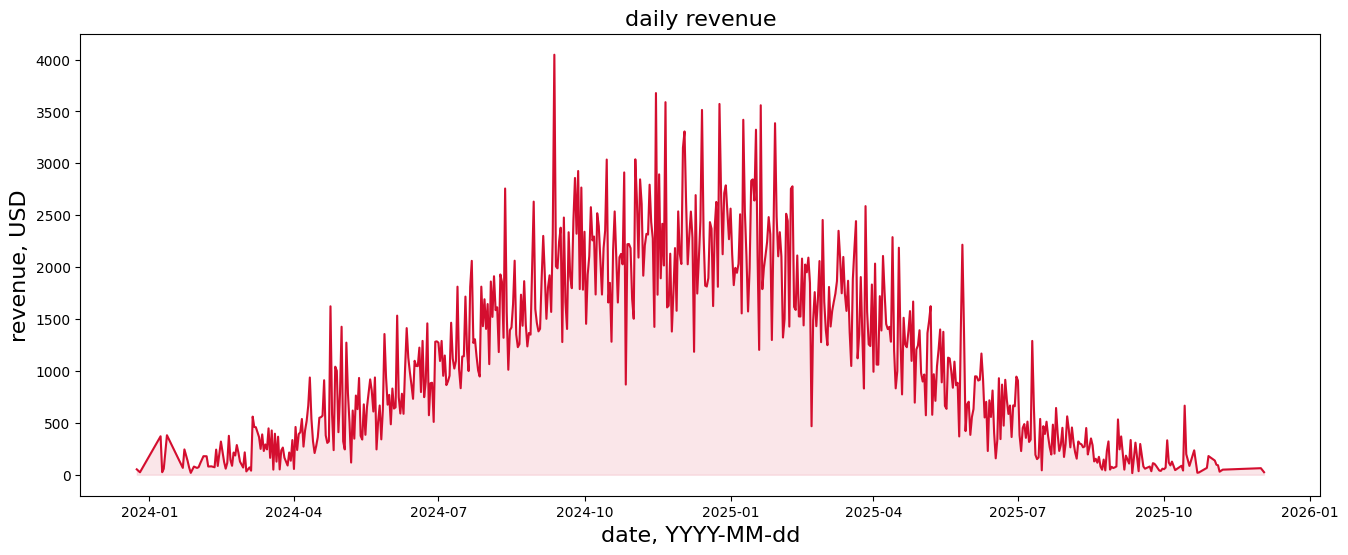

In [20]:
plt.figure(figsize=(16, 6))
plt.plot(daily_rev['date_extracted'], daily_rev['paid_price'], color="#D40E2F")

plt.title('daily revenue', fontsize=16)
plt.xlabel('date, YYYY-MM-dd', fontsize=16)
plt.ylabel('revenue, USD', fontsize=16)
plt.fill_between(daily_rev['date_extracted'], daily_rev['paid_price'], 
                 color="#D40E2F", 
                 alpha=0.1)

plt.show()

#### author metrics

In [21]:
num_unique_author_strings = df_books['author'].nunique()

print(f"Number of unique author entries: {num_unique_author_strings}")

Number of unique author entries: 362


In [22]:
def author_setting(author_str):
    if pd.isna(author_str):
        return ""
    authors = sorted([a.strip().lower() for a in str(author_str).split(',')])
    return ", ".join(authors)

In [23]:
df_books['author_set'] = df_books['author'].apply(author_setting)

In [24]:
print(f"Number of unique sets of authors: {df_books['author_set'].nunique()}")

Number of unique sets of authors: 293


#### unique users

In [25]:
fields = ['name', 'address', 'phone', 'email']

G = nx.Graph()
G.add_nodes_from(df_users['id'])

for combo in combinations(fields, 3):
    groups = df_users.groupby(list(combo))
    for _, group in groups:
        if len(group) > 1:
            uids = group['id'].tolist()
            for i in range(len(uids)):
                for j in range(i + 1, len(uids)):
                    G.add_edge(uids[i], uids[j])

unique_user_clusters = list(nx.connected_components(G))
print(f"Number of real unique users: {len(unique_user_clusters)}")

Number of real unique users: 2663


#### most popular author/set

In [26]:
df_sales_authors = df_orders.merge(df_books[['id', 'author_set']], left_on='book_id', right_on='id')

popularity = df_sales_authors.groupby('author_set')['quantity'].sum().sort_values(ascending=False)

most_popular = popularity.idxmax()
sales_count = popularity.max()

In [27]:
print(f"Most popular author(s): {most_popular}")
print(f"Total books sold: {sales_count}")

Most popular author(s): hershel treutel, miss modesto denesik, sen. trula bosco
Total books sold: 163


#### top spending customers

In [28]:
user_to_cluster = {}
for idx, cluster in enumerate(unique_user_clusters):
    for uid in cluster:
        user_to_cluster[uid] = idx

df_orders['cluster_id'] = df_orders['user_id'].map(user_to_cluster)

spending_per_user = df_orders.groupby('cluster_id')['paid_price'].sum()
top_cluster_idx = spending_per_user.idxmax()
total_spent = spending_per_user.max()

top_customer_ids = list(unique_user_clusters[top_cluster_idx])

top_customer_names = df_users[df_users['id'].isin(top_customer_ids)]['name'].unique().tolist()

In [29]:
print(f"Top customer names: {top_customer_names}")
print(f"Top customer total spending: ${total_spent:.2f}")
print(f"Original user_id values for this customer: {top_customer_ids}")

Top customer names: ['Catina Altenwerth', 'Tilda Hartmann']
Top customer total spending: $1312.84
Original user_id values for this customer: [55058, 55420, 53583]


In [30]:
top_customer_rows = df_users[df_users['id'].isin(top_customer_ids)]
top_customer_rows.head()

,id,name,address,phone,email
305,53583,Catina Altenwerth,"3740 Lemke Creek, Konopelskihaven, ME 71939-4348",100 233 1733,lilia_mueller@sanford-franecki.test
1306,55058,Tilda Hartmann,"3740 Lemke Creek, Konopelskihaven, ME 71939-4348",100 233 1733,lilia_mueller@sanford-franecki.test
1752,55420,Catina Altenwerth,"Apt. 624 9824 Effie Key, Port Virgie, VT 12128",100 233 1733,lilia_mueller@sanford-franecki.test


### saving dfs for streamlit app

In [31]:
DATA_ID = 'DATA2'
FOLDER_PATH = f'dashboard_data/{DATA_ID}'

top_customer_rows.to_csv(f'{FOLDER_PATH}/top_customer_details.csv', index=False)

np.savetxt(f'{FOLDER_PATH}/top_customer_total_spent.txt', [total_spent], fmt='%.2f')

top_5_days.to_csv(f'{FOLDER_PATH}/top_5_days.csv', index=False)

unique_author_set_num = df_books['author_set'].nunique()

with open(f"{FOLDER_PATH}/unique_authors.txt", "w") as f:
    f.write(str(unique_author_set_num))

unique_users_num = len(unique_user_clusters)

with open(f"{FOLDER_PATH}/unique_users.txt", "w") as f:
    f.write(str(unique_users_num))

popularity.to_csv(f'{FOLDER_PATH}/author_popularity.csv')

top_customer_rows.to_csv('top_customer_details.csv', index=False)

daily_rev.to_csv(f'{FOLDER_PATH}/daily_revenue.csv', index=False)